In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "duckdb",
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "pyarrow",
#     "scikit-learn",
#     "seaborn",
# ]
#
# [tool.uv]
# exclude-newer = "2025-09-03T14:42:26.441083777+02:00"
# ///

In [2]:
import duckdb
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from __future__ import annotations
from typing import Iterable, Optional, List, Dict, Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pathlib import Path

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_theme(style="whitegrid")

In [4]:
samples_path = Path("../data/samples")
seed = 42
n = 10000

In [5]:
%%time
duckdb.sql(f"""
    COPY (
        SELECT *,
            CASE
                WHEN row_pct <= 0.6 THEN 'train'
                WHEN row_pct <= 0.8 THEN 'valid'
                ELSE 'test'
            END AS split
        FROM (
            SELECT *,
                ROW_NUMBER() OVER (PARTITION BY year, month, taxonomy_norm ORDER BY Timestamp) * 1.0 /
                COUNT(*) OVER (PARTITION BY year, month, taxonomy_norm) AS row_pct
            FROM read_parquet(
                '{samples_path}/v1.1/year=*/month=*/n={n}/seed={seed}/malicious_benign_balanced.parquet',
                hive_partitioning = true
            )
        )
        ORDER BY Timestamp
    )
    TO '{samples_path}/v1.1/mawiflow_samples_n{n}_seed{seed}_malicious_benign_balanced.parquet'
    (FORMAT PARQUET);
""")

CPU times: user 12min 41s, sys: 3min 25s, total: 16min 7s
Wall time: 53.3 s


In [6]:
samples = pl.read_parquet(f"{samples_path}/v1.1/mawiflow_samples_n{n}_seed{seed}_malicious_benign_balanced.parquet")
samples.head()

Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,…,Fwd TCP Retrans. Count,Bwd TCP Retrans. Count,Total TCP Retrans. Count,Total Connection Flow Time,protocol_name,Label,rule_id,anomaly_id,distance_normal,distance_anomalous,heuristic,hough_sensitive,hough_optimal,hough_conservative,gamma_sensitive,gamma_optimal,gamma_conservative,kl_sensitive,kl_optimal,kl_conservative,pca_sensitive,pca_optimal,pca_conservative,taxonomy,distance,num_detectors,feature_count,duration,annotation_rank,taxonomy_orig,taxonomy_norm,month,n,seed,year,row_pct,split
str,str,i64,str,i64,i64,datetime[μs],i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,…,i64,i64,i64,i64,str,str,u32,u16,f64,f64,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,f64,u8,i32,u32,i64,str,str,str,i64,i64,i64,f64,str
"""80.58.88.3-164.89.55.232-53984…","""80.58.88.3""",53984,"""164.89.55.232""",80,6,2007-01-01 05:00:00.916065,89785188,4171,12045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.608855,5537.168548,52930.058403,4.675575e6,4.0,8.9785188e7,21531.220144,105326.371001,4.809981e6,5.0,8.964115e7,7442.805546,66058.631583,5.000389e6,4.0,0,…,0,0,0,89785188,"""tcp""","""anomalous""",18,12,2.04949,1.60078,"""503""",true,true,true,true,true,false,true,false,false,true,true,true,"""mptpHTTP""",0.44871,9,2,null,1,"""mptpHTTP""","""HTTP""","""01""",10000,42,2007,0.0001,"""train"""
"""161.207.176.53-84.208.112.152-…","""161.207.176.53""",58595,"""84.208.112.152""",2703,6,2007-01-01 05:00:00.918316,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,…,0,0,0,0,"""tcp""","""benign""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""benign""","""benign""","""01""",10000,42,2007,0.000014,"""train"""
"""202.4.92.19-164.89.55.155-4621…","""202.4.92.19""",4621,"""164.89.55.155""",3124,6,2007-01-01 05:00:00.918817,3493113,5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.431388,873278.25,1.0301e6,2.242596e6,250.0,3.493113e6,873278.25,1.0301e6,2.242596e6,250.0,0.0,0.0,0.0,0.0,0.0,1,…,1,0,1,3493113,"""tcp""","""benign""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""benign""","""benign""","""01""",10000,42,2007,0.000028,"""train"""
"""84.46.29.3-164.89.55.232-49585…","""84.46.29.3""",49585,"""164.89.55.232""",80,6,2007-01-01 05:00:00.919440,8030008,9,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.120796,1.003751e6,1.7348e6,4.29115e6,4489.0,8.030008e6,1.003751e6,1.7348e6,4.29115e6,4489.0,0.0,0.0,0.0,0.0,0.0,0,…,1,0,1,8030008,"""tcp""","""anomalous""",18,12,2.04949,1.60078,"""503""",true,true,true,true,true,false,true,false,false,true,true,true,"""mptpHTTP""",0.44871,9,2,null,1,"""mptpHTTP""","""HTTP""","""01""",10000,42,2007,0.0002,"""train"""
"""65.19.89.126-216.115.42.12-349…","""65.19.89.126""",34951,"""216.115.42.12""",53,17,2007-01-01 05:00:00.919810,2254,1,1,12.0,12.0,12.0,12.0,12.0,0.0,12.0,12.0,12.0,0.0,10647.737356,887.311446,2254.0,0.0,2254.0,2254.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,…,0,0,0,2254,"""udp""","""benign""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""benign""","""benign""","""01""",10000,42,2007,0.000041,"""train"""


In [7]:
print(f"Loaded {samples.shape[0]:,} samples with {samples.estimated_size() / (1024**2):,.1f} MB in memory.")

Loaded 30,368,404 samples with 26,411.9 MB in memory.


In [8]:
samples['Label'].value_counts()

Label,count
str,u32
"""anomalous""",15184202
"""benign""",15184202


In [9]:
taxonomy_counts = samples['taxonomy_norm'].value_counts()\
    .sort(by='count', descending=True)\
    .to_pandas()

taxonomy_counts

,taxonomy_norm,count
0,benign,15184202
1,Multi. points,1960000
2,Network scan TCP,1960000
3,Network scan UDP,1935913
4,HTTP,1906225
5,Alpha flow,1779691
6,Other,1413357
7,DoS,1373117
8,Network scan ICMP,1262168
9,Port scan,931409


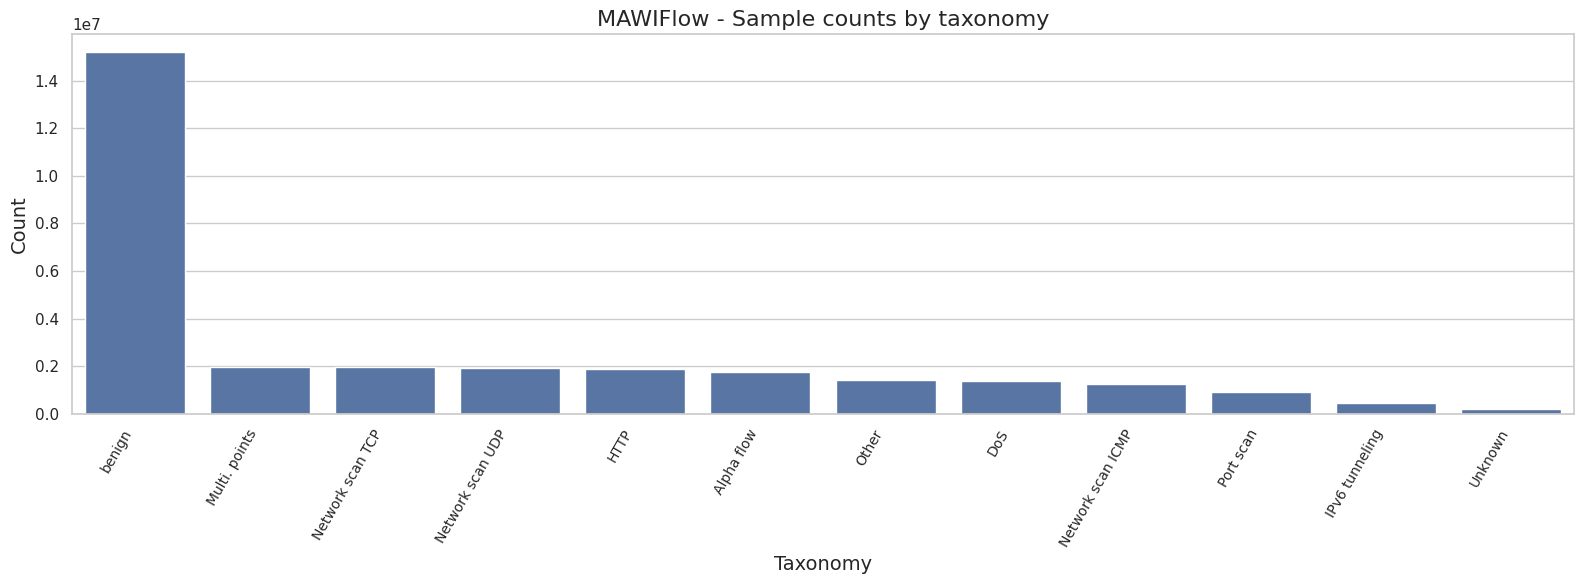

In [10]:
plt.figure(figsize=(16, 6))
sns.barplot(data=taxonomy_counts, x='taxonomy_norm', y='count')

plt.xticks(rotation=60, ha='right', fontsize=10)
plt.title('MAWIFlow - Sample counts by taxonomy', fontsize=16)
plt.xlabel('Taxonomy', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
taxonomy_monthly = (
    samples
    .group_by(['year', 'month', 'taxonomy_norm'])
    .agg(pl.len())
    .with_columns([
        pl.date(
            year=pl.col('year').cast(pl.Int32),
            month=pl.col('month').cast(pl.Int32),
            day=1
        ),
        pl.col('len').alias('count')
    ])
    .select(['date', 'taxonomy_norm', 'count'])
    .sort(['date', 'taxonomy_norm'])
    .to_pandas()
    .pivot(index='date', columns='taxonomy_norm', values='count')
)

In [12]:
taxonomy_monthly.head()

taxonomy_norm,Alpha flow,DoS,HTTP,IPv6 tunneling,Multi. points,Network scan ICMP,Network scan TCP,Network scan UDP,Other,Port scan,Unknown,benign
date,,,,,,,,,,,,
2007-01-01,10000.0,3921.0,10000.0,34.0,10000.0,10000.0,10000.0,10000.0,6761.0,1775.0,NaN,72491.0
2007-02-01,10000.0,10000.0,10000.0,435.0,10000.0,10000.0,10000.0,10000.0,10000.0,2491.0,NaN,82926.0
2007-03-01,10000.0,8057.0,10000.0,338.0,10000.0,10000.0,10000.0,10000.0,10000.0,7870.0,NaN,86265.0
2007-04-01,10000.0,6818.0,10000.0,111.0,10000.0,10000.0,10000.0,10000.0,10000.0,136.0,8.0,77073.0
2007-05-01,10000.0,10000.0,10000.0,202.0,10000.0,10000.0,10000.0,10000.0,10000.0,2656.0,NaN,82858.0


In [13]:
taxonomy_monthly_splits = (
    samples
    .group_by(['split', 'year', 'month', 'taxonomy_norm'])
    .agg(pl.len())
    .with_columns([
        pl.date(
            year=pl.col('year').cast(pl.Int32),
            month=pl.col('month').cast(pl.Int32),
            day=1
        ),
        pl.col('len').alias('count')
    ])
    .select(['split', 'date', 'taxonomy_norm', 'count'])
    .sort(['date', 'taxonomy_norm', 'split'])
    .to_pandas()
)

In [14]:
taxonomy_monthly_splits.pivot(
    index='date',
    columns=['taxonomy_norm', 'split'],
    values='count'
).fillna(0).astype(int)

taxonomy_norm Alpha flow               DoS              HTTP              \
split               test train valid  test train valid  test train valid   
date                                                                       
2007-01-01          2000  6000  2000   785  2352   784  2000  6000  2000   
2007-02-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2007-03-01          2000  6000  2000  1612  4834  1611  2000  6000  2000   
2007-04-01          2000  6000  2000  1364  4090  1364  2000  6000  2000   
2007-05-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2007-06-01          1196  3587  1196  2000  6000  2000  2000  6000  2000   
2007-07-01          2000  6000  2000     0     0     0  2000  6000  2000   
2007-08-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2007-09-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2007-10-01          2000  6000  2000   462  1384   462  2000  6000  2000   
2007-11-01          2000  6000  2000  1717  5148  1716  2000  6000  2000   
2007-12-01          2000  6000  2000    96   287    96  2000  6000  2000   
2008-01-01          2000  6000  2000   443  1327   443  2000  6000  2000   
2008-02-01          2000  6000  2000   146   436   146  2000  6000  2000   
2008-03-01          2000  6000  2000  1775  5323  1775  2000  6000  2000   
2008-04-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-05-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-06-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-07-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-08-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-09-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-10-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-11-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2008-12-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2009-01-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2009-02-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2009-03-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2009-04-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2009-05-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2009-06-01           184   550   183  2000  6000  2000  2000  6000  2000   
2009-07-01          2000  6000  2000    55   163    54  2000  6000  2000   
2009-08-01          1107  3320  1107     8    22     8  2000  6000  2000   
2009-09-01          1295  3882  1294   383  1148   383  2000  6000  2000   
2009-10-01           212   633   211  2000  6000  2000  2000  6000  2000   
2009-11-01          2000  6000  2000   671  2011   671  2000  6000  2000   
2009-12-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2010-01-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2010-02-01           407  1220   407  2000  6000  2000  2000  6000  2000   
2010-03-01          2000  6000  2000     0     0     0  2000  6000  2000   
2010-04-01          2000  6000  2000    18    52    17  2000  6000  2000   
2010-05-01          2000  6000  2000  1230  3688  1230  2000  6000  2000   
2010-06-01          2000  6000  2000   738  2212   737  2000  6000  2000   
2010-07-01          2000  6000  2000  1047  3140  1047  2000  6000  2000   
2010-08-01          2000  6000  2000  1202  3605  1202  2000  6000  2000   
2010-09-01           831  2491   831  2000  6000  2000  2000  6000  2000   
2010-10-01          1752  5253  1751  2000  6000  2000  2000  6000  2000   
2010-11-01           653  1957   652  2000  6000  2000  2000  6000  2000   
2010-12-01          2000  6000  2000  2000  6000  2000  2000  6000  2000   
2011-01-01          2000  6000  2000   899  2695   899  2000  6000  2000   
2011-02-01          2000  6000  2000    44   130

In [15]:
(
    samples
    .group_by(['split', 'year', 'taxonomy_norm'])
    .agg(pl.len())
    .with_columns(pl.col('len').alias('count'))
    .select(['split', 'year', 'taxonomy_norm', 'count'])
    .sort(['year', 'taxonomy_norm', 'split'])
    .to_pandas()
    .pivot(index='year', columns=['taxonomy_norm', 'split'], values='count')
    .fillna(0)
    .astype(int)
)

taxonomy_norm Alpha flow                  DoS                 HTTP         \
split               test  train  valid   test  train  valid   test  train   
year                                                                        
2007               23196  69587  23196  16036  48095  16033  24000  72000   
2008               24000  72000  24000  20364  61086  20364  24000  72000   
2009               18798  56385  18795  17117  51344  17116  24000  72000   
2010               19643  58921  19641  16235  48697  16233  24000  72000   
2011               19936  59805  19936  18943  56825  18942  24000  72000   
2012               21310  63922  21308  20346  61038  20346  24000  72000   
2013               24000  72000  24000   9947  29824   9942  24000  72000   
2014               24000  72000  24000  22285  66855  22285  24000  72000   
2015               20934  62795  20931  24000  72000  24000  24000  72000   
2016               24000  72000  24000  22901  68699  22899  24000  72000   
2017               18583  55744  18581   2985   8937   2979  22000  66000   
2018               19713  59131  19712  14434  43291  14430  24000  72000   
2019               23592  70775  23592  17777  53325  17776  24000  72000   
2020               24000  72000  24000  15141  45417  15140  24000  72000   
2021               24000  72000  24000  17008  51020  17007  24000  72000   
2022                2000   6000   2000    207    619    206   2000   6000   
2023               14140  42418  14139  14087  42260  14087  15107  45321   
2024               10107  30318  10107   4839  14511   4837   6141  18412   

taxonomy_norm        IPv6 tunneling               Multi. points                \
split          valid           test  train  valid          test  train  valid   
year                                                                            
2007           24000           1446   4322   1442         24000  72000  24000   
2008           24000            795   2360    788         24000  72000  24000   
2009           24000           7822  23448   7816         24000  72000  24000   
2010           24000          24000  72000  24000         24000  72000  24000   
2011           24000          24000  72000  24000         24000  72000  24000   
2012           24000          18047  54137  18047         24000  72000  24000   
2013           24000            138    392    132         24000  72000  24000   
2014           24000            392   1158    387         24000  72000  24000   
2015           24000           2437   7297   2434         24000  72000  24000   
2016           24000            972   2892    965         24000  72000  24000   
2017           22000            388   1150    385         22000  66000  22000   
2018           24000            542   1610    538         24000  72000  24000   
2019           24000           2118   6339   2116         24000  72000  24000   
2020           24000           4716  14127   4710         24000  72000  24000   
2021           24000           1616   4823   1608         24000  72000  24000   
2022            2000             22     64     22          2000   6000   2000   
2023           15107           3301   9886   3295         16000  48000  16000   
2024            6137             58    171     58         16000  48000  16000   

taxonomy_norm Network scan ICMP               Network scan TCP                \
split                      test  train  valid             test  train  valid   
year                                                                           
2007                      24000  72000  24000            24000  72000  24000   
2008                      24000  72000  24000            24000  72000  24000   
2009                      21437  64310  21437            24000  72000  24000   
2010                      14129  42379  14128            24000  72000  24000   
2011                       9808  29414   9805            24000  72000  24000   
2012                      22898  68692  

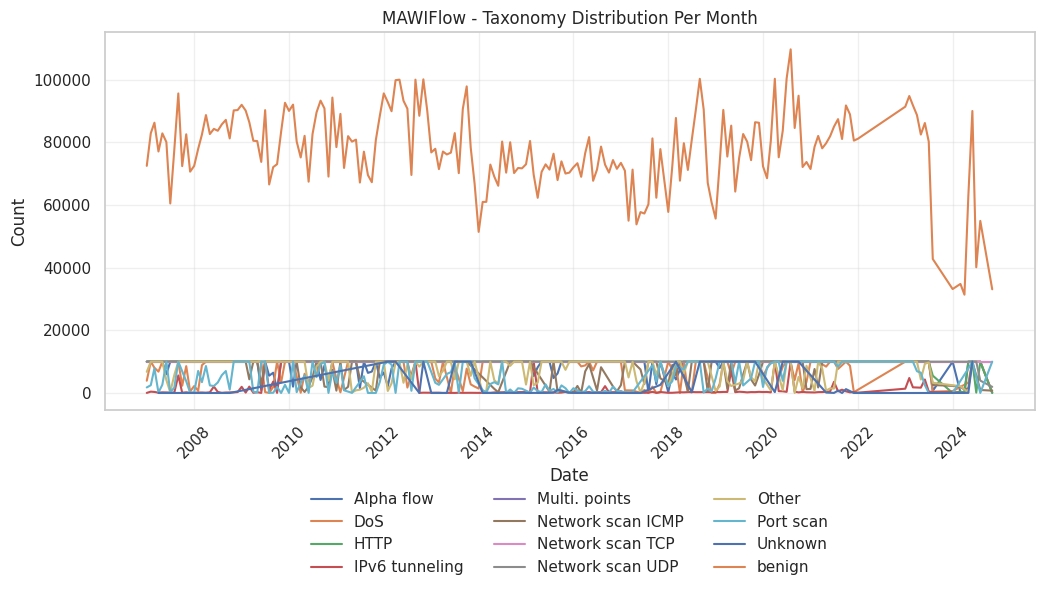

In [16]:
plt.figure(figsize=(12, 6))
for column in taxonomy_monthly.columns:
    sns.lineplot(
        x=taxonomy_monthly.index,
        y=taxonomy_monthly[column],
        label=column
    )

plt.title("MAWIFlow - Taxonomy Distribution Per Month")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

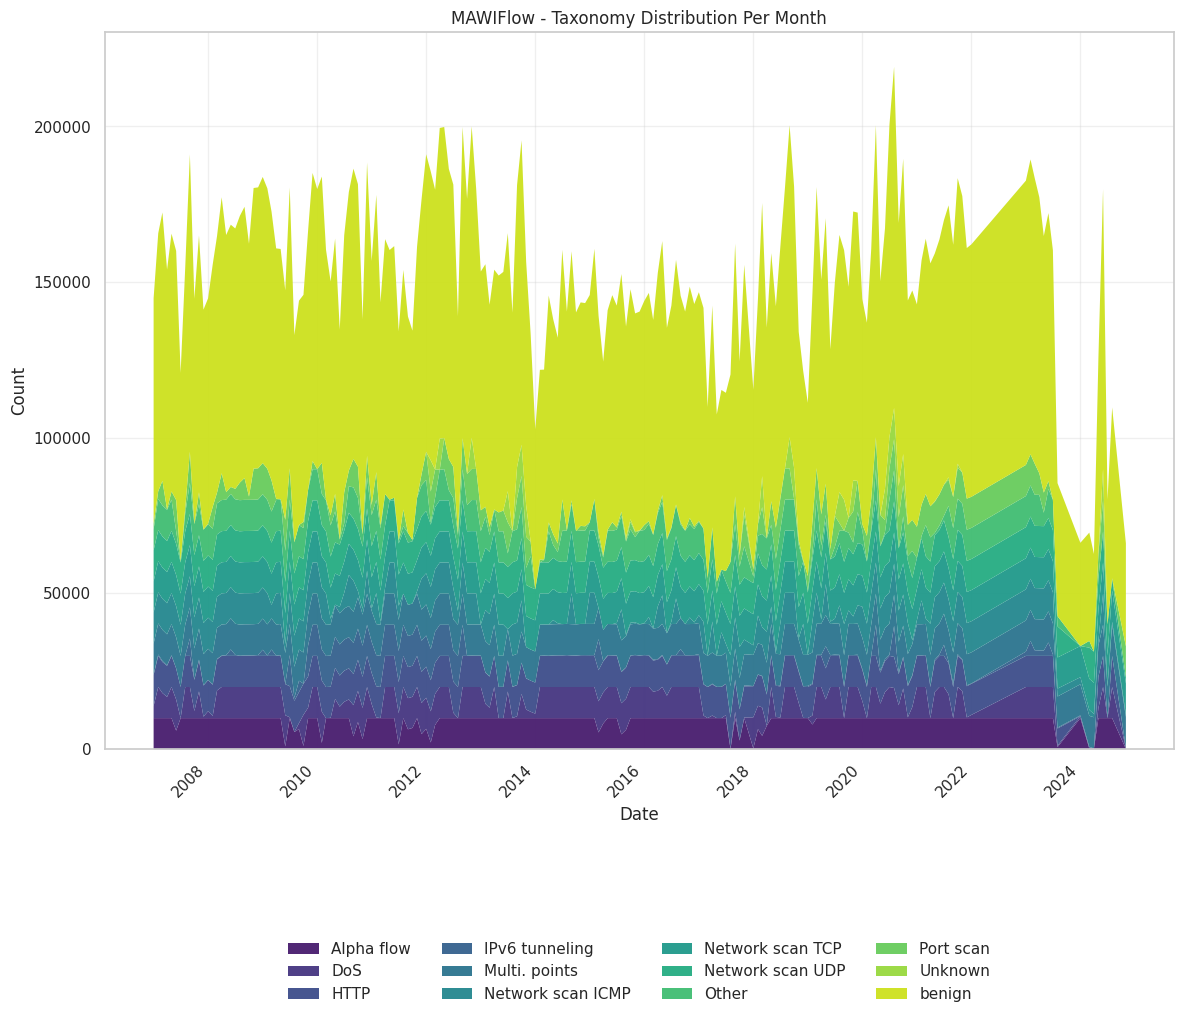

In [17]:
plt.figure(figsize=(12, 10))
tax_cols = list(taxonomy_monthly.columns)
tax_palette = sns.color_palette("viridis", n_colors=len(tax_cols))
taxonomy_monthly[tax_cols].fillna(0).plot.area(
    stacked=True,
    color=tax_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("MAWIFlow - Taxonomy Distribution Per Month")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

In [18]:
taxonomy_monthly_rel = taxonomy_monthly.div(taxonomy_monthly.sum(axis=1), axis=0).drop(columns=['benign'])

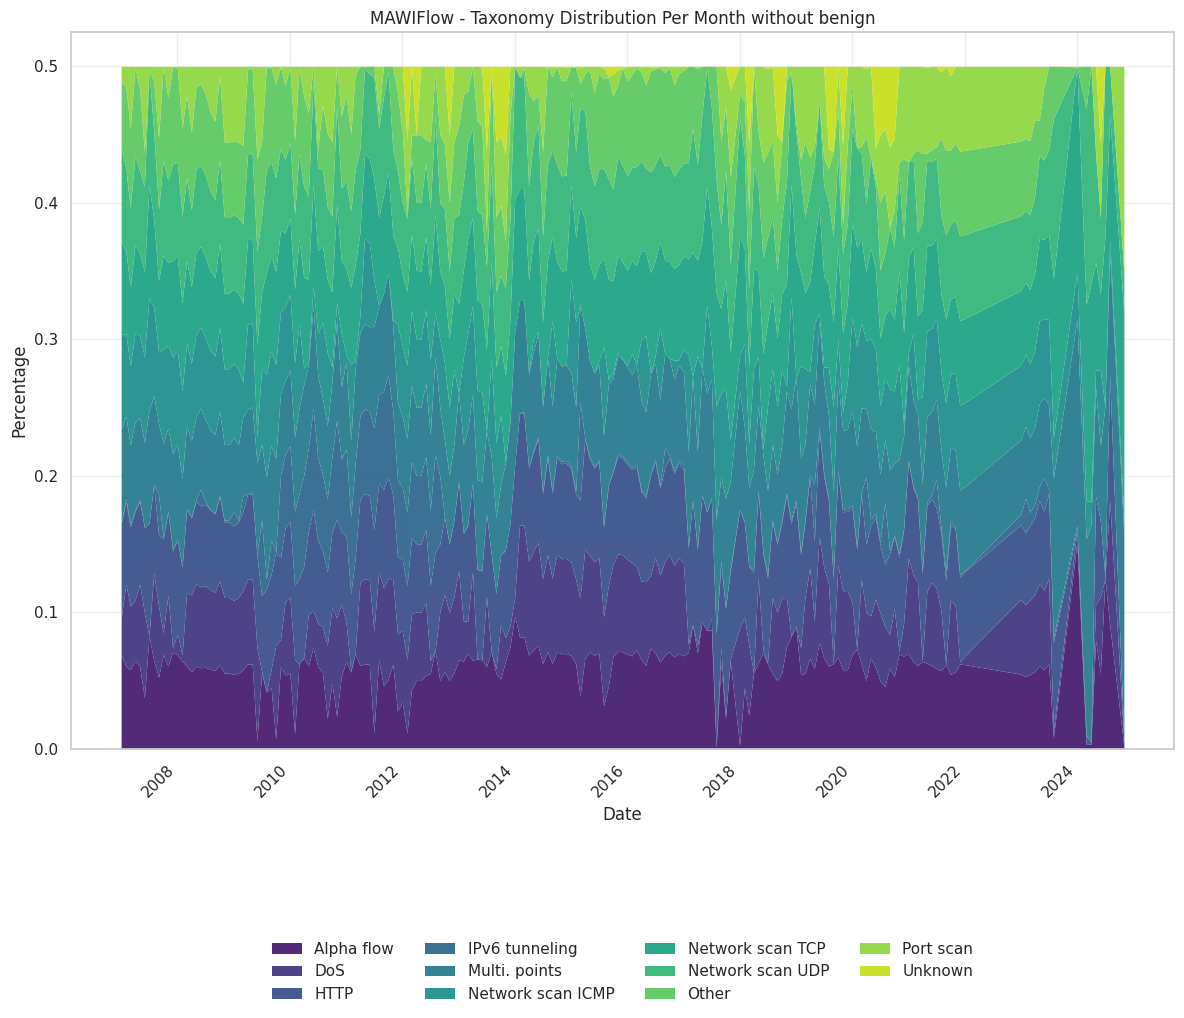

In [19]:
plt.figure(figsize=(12, 10))
tax_cols = list(taxonomy_monthly_rel.columns)
tax_palette = sns.color_palette("viridis", n_colors=len(tax_cols))
taxonomy_monthly_rel[tax_cols].fillna(0).plot.area(
    stacked=True,
    color=tax_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("MAWIFlow - Taxonomy Distribution Per Month without benign")
plt.xlabel("Date")
plt.ylabel("Percentage")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

In [20]:
features = [
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Total",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "Fwd RST Flags",
    "Bwd RST Flags",
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "FIN Flag Count",
    "SYN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count",
    "CWR Flag Count",
    "ECE Flag Count",
    "Down/Up Ratio",
    "Average Packet Size",
    "Fwd Segment Size Avg",
    "Bwd Segment Size Avg",
    "Fwd Bytes/Bulk Avg",
    "Fwd Packet/Bulk Avg",
    "Fwd Bulk Rate Avg",
    "Bwd Bytes/Bulk Avg",
    "Bwd Packet/Bulk Avg",
    "Bwd Bulk Rate Avg",
    "Subflow Fwd Packets",
    "Subflow Fwd Bytes",
    "Subflow Bwd Packets",
    "Subflow Bwd Bytes",
    "FWD Init Win Bytes",
    "Bwd Init Win Bytes",
    "Fwd Act Data Pkts",
    "Bwd Act Data Pkts",
    "Fwd Seg Size Min",
    "Bwd Seg Size Min",
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Mean",
    "Idle Std",
    "Idle Max",
    "Idle Min",
    "ICMP Code",
    "ICMP Type",
    "Fwd TCP Retrans. Count",
    "Bwd TCP Retrans. Count",
    "Total TCP Retrans. Count",
    "Total Connection Flow Time",
]

In [21]:
# One-cell PCA-by-year for a Polars DataFrame
# - Standardizes features per year (no leakage)
# - Computes per-feature variance (pre-standardization) per year
# - Runs PCA per year and returns explained variance ratios and loadings
# Usage (at bottom): res = pca_by_year(df, year_col="year", exclude=["label"], sample_per_year=100_000, n_components=20)

def pca_by_year(
    df: pl.DataFrame,
    year_col: str = "year",
    exclude: Optional[Iterable[str]] = None,
    sample_per_year: Optional[int] = None,
    n_components: Optional[int] = None,
    drop_nulls: bool = True,
    seed: int = 42,
) -> Dict[str, pl.DataFrame]:
    """
    Run PCA on numeric features per year.
    Returns dict with:
      - feature_variance_by_year: long table [year, feature, variance]
      - explained_variance_ratio_by_year: wide table [year, pc1..pcK]
      - loadings_by_year: long table [year, feature, pc, loading]
    """
    if year_col not in df.columns:
        raise ValueError(f"year_col='{year_col}' not in DataFrame.")

    excl = set(exclude or [])
    # Determine numeric feature columns (exclude year + any listed columns)
    numeric_cols = [
        c for c, dt in zip(df.columns, df.dtypes)
        if (dt.is_numeric() and c != year_col and c not in excl)
    ]
    if not numeric_cols:
        raise ValueError("No numeric feature columns found after exclusions.")

    # Ensure year is integer-like for sorting/joins
    years = sorted(pl.Series(df[year_col]).cast(pl.Int64).unique().to_list())

    var_rows = []
    evr_rows = []
    load_rows = []

    rng = np.random.default_rng(seed)

    for y in years:
        dfy = df.filter(pl.col(year_col) == y).select([year_col] + numeric_cols)
        if drop_nulls:
            dfy = dfy.drop_nulls()
        else:
            dfy = dfy.fill_null(0)

        if dfy.height == 0:
            continue

        # Optional downsample (row-wise) to bound PCA cost
        feats = dfy.select(numeric_cols)
        if sample_per_year is not None and feats.height > sample_per_year:
            # Use numpy choice on row indices for speed
            idx = rng.choice(feats.height, size=sample_per_year, replace=False)
            feats = feats.take(idx.tolist())

        if feats.height < 2 or len(numeric_cols) < 2:
            continue

        X = feats.to_numpy()

        # 1) Per-feature variance BEFORE standardization (drift signal)
        v = feats.select([pl.col(c).var().alias(c) for c in numeric_cols])
        v = v.with_columns(pl.lit(int(y)).alias(year_col))
        var_rows.append(v)

        # 2) PCA on standardized data
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
        k = min(
            n_components if n_components is not None else Xs.shape[1],
            Xs.shape[1],
            Xs.shape[0]
        )
        pca = PCA(n_components=k, svd_solver="auto", random_state=seed)
        pca.fit(Xs)

        # 2a) Explained variance ratio (wide)
        evr_dict = {f"pc{i+1}": float(pca.explained_variance_ratio_[i]) for i in range(k)}
        evr_dict[year_col] = int(y)
        evr_rows.append(evr_dict)

        # 2b) Loadings (long): component vectors per feature
        comps = pca.components_  # shape [k, n_features]
        # Build long table for this year
        load_rows.append(
            pl.DataFrame({
                "year": [int(y)] * (k * len(numeric_cols)),
                "feature": sum([[f]*k for f in numeric_cols], []),
                "pc": [i+1 for _ in numeric_cols for i in range(k)],
                "loading": comps.T.reshape(-1).tolist(),
            })
        )

    # Assemble outputs
    feature_var = pl.concat(var_rows, how="vertical") if var_rows else pl.DataFrame()
    if feature_var.height > 0:
        feature_var = feature_var.unpivot(
            index=[year_col],
            on=None,  # all columns except index
            variable_name="feature",
            value_name="variance"
        )

    if evr_rows:
        # Normalize to same number of PCs across years (pad with NaN)
        max_k = max(len(d) - 1 for d in evr_rows)
        for d in evr_rows:
            for i in range(1, max_k + 1):
                d.setdefault(f"pc{i}", np.nan)
        explained = pl.DataFrame(evr_rows).select(
            [year_col] + [f"pc{i}" for i in range(1, max_k + 1)]
        ).sort(year_col)
    else:
        explained = pl.DataFrame()

    loadings = pl.concat(load_rows, how="vertical") if load_rows else pl.DataFrame()

    return {
        "feature_variance_by_year": feature_var,
        "explained_variance_ratio_by_year": explained,
        "loadings_by_year": loadings,
    }

In [22]:
res = pca_by_year(
    samples.select(features + ['year']),
    year_col="year",
)

In [23]:
# PCs needed to hit a target variance per year
def plot_pcs_for_target(res, target=0.95):
    evr = res["explained_variance_ratio_by_year"]
    if evr.is_empty():
        print("No EVR data.")
        return
    evr_pd = evr.to_pandas().set_index("year").sort_index()
    cum = evr_pd.apply(np.cumsum, axis=1)
    pcs_needed = cum.apply(lambda row: np.searchsorted(row.values, target) + 1, axis=1)
    df = pcs_needed.reset_index()
    df.columns = ["year", "pcs_needed"]

    plt.figure(figsize=(7, 4))
    ax = sns.lineplot(data=df, x="year", y="pcs_needed", marker="o")
    ax.axhline(df["pcs_needed"].mean(), linestyle="--")
    ax.set_title(f"PCs needed to reach {int(target*100)}% variance")
    ax.set_xlabel("Year"); ax.set_ylabel("#PCs")
    plt.tight_layout()

In [24]:
# Heatmap of per-feature raw variance over years (log scale)
def plot_feature_variance_heatmap(res, top_n_features=40):
    fv = res["feature_variance_by_year"]
    if fv.is_empty():
        print("No per-feature variance data.")
        return
    fv_pd = fv.to_pandas()
    M = fv_pd.pivot(index="year", columns="feature", values="variance").sort_index()
    keep = M.var().sort_values(ascending=False).head(top_n_features).index
    M = M[keep].clip(lower=1e-12)  # avoid log(0)

    plt.figure(figsize=(min(12, 0.25*len(keep)+4), max(4, 0.35*len(M.index))))
    ax = sns.heatmap(np.log10(M), cbar_kws={"label": "log10(variance)"})
    ax.set_title("Per-feature variance by year (top features)")
    ax.set_xlabel("Feature"); ax.set_ylabel("Year")
    plt.xticks(rotation=90)
    plt.tight_layout()

In [25]:
# Bar chart: top-|loading| features for a given PC and year
def plot_top_loadings(res, year, pc=1, top_k=20):
    L = res["loadings_by_year"]
    if L.is_empty():
        print("No loadings data.")
        return
    sel = (L.filter((pl.col("year")==year) & (pl.col("pc")==pc))
             .with_columns(pl.col("loading").abs().alias("abs_loading"))
             .sort("abs_loading", descending=True)
             .head(top_k)
             .select("feature","loading","abs_loading"))
    if sel.is_empty():
        print(f"No loadings for year={year}, pc={pc}.")
        return
    s = sel.to_pandas().sort_values("abs_loading")

    plt.figure(figsize=(8, max(4, 0.35*len(s))))
    ax = sns.barplot(data=s, x="loading", y="feature", orient="h")
    ax.set_title(f"Top |loadings| — Year {year}, PC{pc}")
    ax.set_xlabel("Loading"); ax.set_ylabel("Feature")
    plt.tight_layout()

In [26]:
# PC drift: cosine similarity of PC1 loadings across years
def plot_pc_similarity_heatmap(res, pc=1):
    L = res["loadings_by_year"]
    if L.is_empty():
        print("No loadings data.")
        return
    Lp = L.filter(pl.col("pc")==pc).to_pandas()
    if Lp.empty:
        print(f"No loadings for PC{pc}.")
        return
    W = Lp.pivot_table(index="feature", columns="year", values="loading").fillna(0.0)
    A = W.values  # features × years
    norms = np.linalg.norm(A, axis=0, keepdims=True); norms[norms==0] = 1.0
    S = (A.T @ A) / (norms.T @ norms)  # cosine similarity
    years = W.columns.to_numpy()

    plt.figure(figsize=(6.5, 5.5))
    ax = sns.heatmap(S, vmin=-1, vmax=1, square=True, center=0,
                     xticklabels=years, yticklabels=years,
                     cbar_kws={"label": "Cosine similarity"})
    ax.set_title(f"PC{pc} loading similarity across years")
    ax.set_xlabel("Year"); ax.set_ylabel("Year")
    plt.tight_layout()

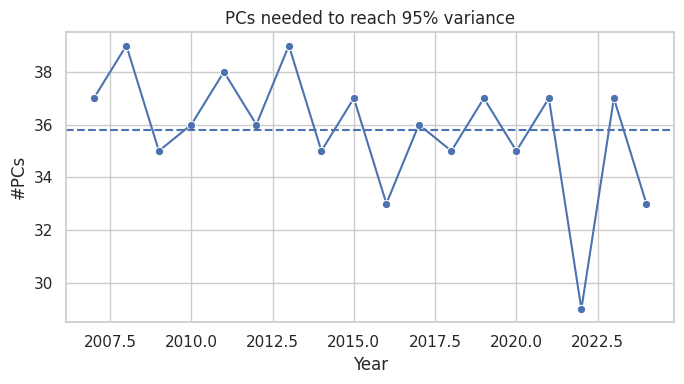

In [27]:
plot_pcs_for_target(res, target=0.95)

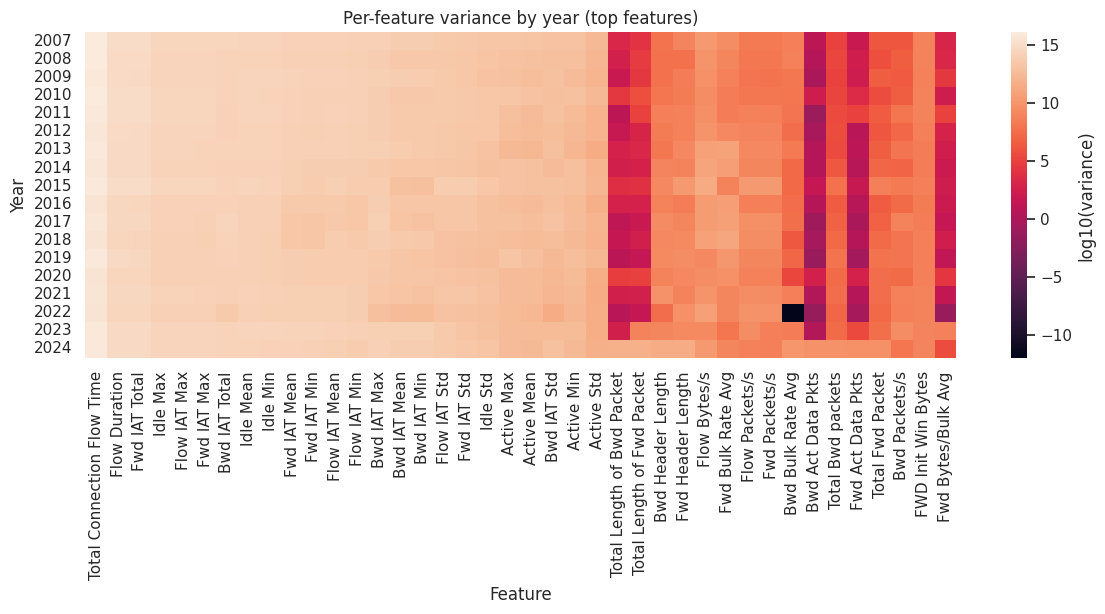

In [28]:
plot_feature_variance_heatmap(res, top_n_features=40)

In [29]:
# plot_pc_similarity_heatmap(res, pc=1)

In [30]:
# mptplaHTTP_flows = samples.filter(pl.col("taxonomy_norm") == "mptplaHTTP").to_pandas()

# plt.figure(figsize=(10, 7))
# sns.boxplot(
#     data=mptplaHTTP_flows,
#     x="year",
#     y="Flow Duration"
# )
# plt.title('Flow Duration Boxplot per Year (taxonomy_norm == "mptplaHTTP")')
# plt.xlabel("Year")
# plt.ylabel("Flow Duration")
# plt.tight_layout()
# plt.show()